FINAL MODEL COMPARISON

PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1 Score     AUC
Model                                                             
ELM                    0.9102     0.8712  0.9173    0.8911  0.9454
Random Forest          0.9583     0.9453  0.9561    0.9481  0.9842
XGBoost                0.9583     0.9561  0.9401    0.9474  0.9799
Logistic Regression    0.9037     0.8788  0.8947    0.8809  0.9374

MODEL STABILITY (%)
                     Stability (%)
Model                             
ELM                          3.914
Random Forest                4.676
XGBoost                      4.003
Logistic Regression          6.011

COMPUTATION TIME
                     Avg Time (s)  Total Time (s)
Model                                            
ELM                        0.0295          0.2946
Random Forest              0.7317          7.3175
XGBoost                    0.0753          0.7531
Logistic Regression        0.0385          0.3851

P

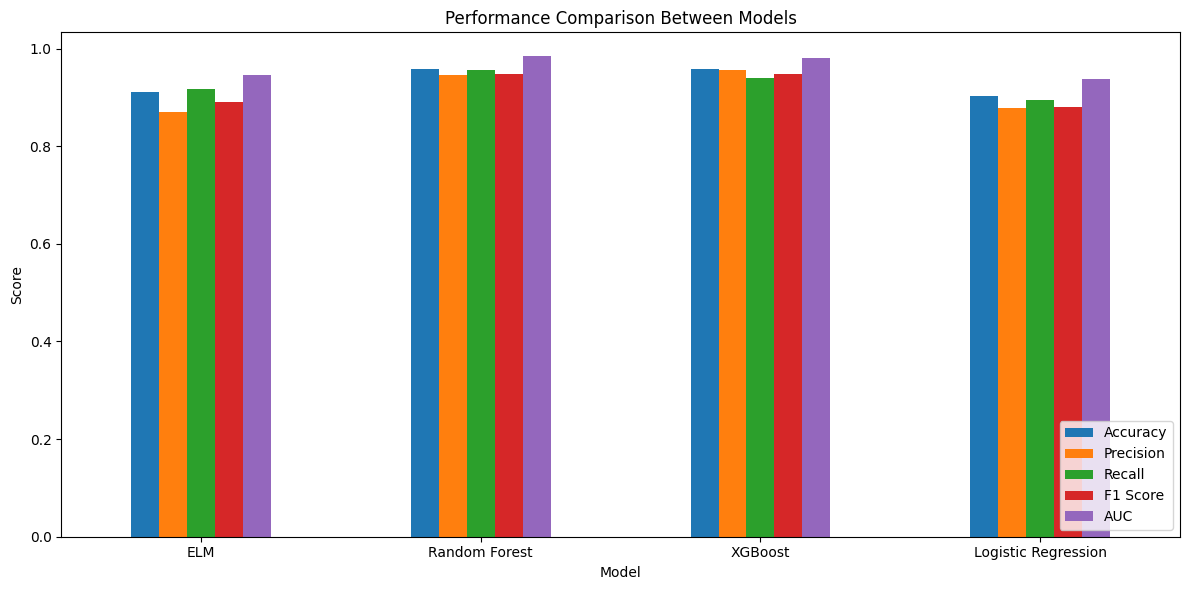

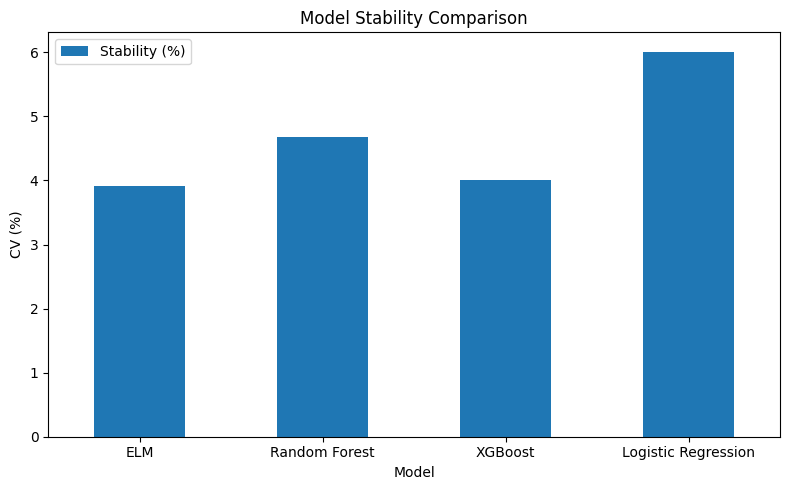

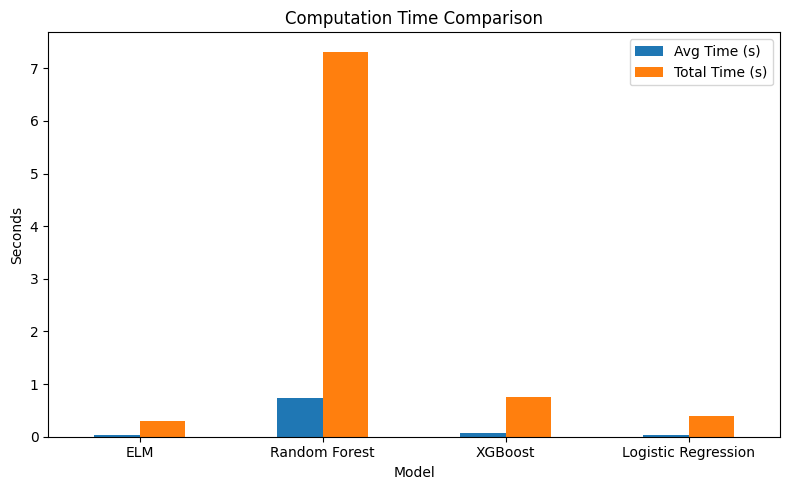


FILES GENERATED:
- comparison_performance.csv
- comparison_stability.csv
- comparison_computation_time.csv
- comparison_performance_ranking.csv
- comparison_stability_ranking.csv
- comparison_time_ranking.csv
- comparison_overall_ranking.csv


In [3]:
# ============================================================
# FINAL MODEL COMPARISON
# ELM vs RF vs XGB vs LR
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD MODEL SUMMARY
# ============================================================

def load_all_models():

    elm = pd.read_csv("elm_model_summary.csv")
    rf = pd.read_csv("rf_model_summary.csv")
    xgb = pd.read_csv("xgb_model_summary.csv")
    lr = pd.read_csv("lr_model_summary.csv")

    df = pd.concat([elm, rf, xgb, lr], ignore_index=True)

    df = df.set_index("Model")

    return df


# ============================================================
# PERFORMANCE TABLE
# ============================================================

def performance_table(df):

    perf = df[[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]]

    return perf.round(4)


# ============================================================
# STABILITY TABLE
# ============================================================

def stability_table(df):

    stab = df[["Stability (%)"]]

    return stab.round(3)


# ============================================================
# COMPUTATION TIME
# ============================================================

def computation_time_table(df):

    time_df = df[[
        "Avg Time (s)",
        "Total Time (s)"
    ]]

    return time_df.round(4)


# ============================================================
# PERFORMANCE RANKING
# ============================================================

def ranking_performance(performance):

    rank = performance.copy()

    for col in rank.columns:
        rank[col] = rank[col].rank(ascending=False)

    rank["Total Rank"] = rank.sum(axis=1)

    rank = rank.sort_values("Total Rank")

    return rank


# ============================================================
# STABILITY RANKING
# ============================================================

def ranking_stability(df):

    stability = df[["Stability (%)"]].copy()

    stability["Rank Stability"] = stability["Stability (%)"].rank(ascending=True)

    stability = stability.sort_values("Rank Stability")

    return stability.round(3)


# ============================================================
# TRAINING TIME RANKING
# ============================================================

def ranking_time(df):

    time_df = df[["Avg Time (s)"]].copy()

    time_df["Rank Time"] = time_df["Avg Time (s)"].rank(ascending=True)

    time_df = time_df.sort_values("Rank Time")

    return time_df.round(4)


# ============================================================
# OVERALL RANKING
# ============================================================

def overall_ranking(performance, stability, time_df):

    perf_rank = performance.rank(ascending=False)

    perf_rank["Performance Rank"] = perf_rank.mean(axis=1)

    stability_rank = stability["Stability (%)"].rank(ascending=True)

    time_rank = time_df["Avg Time (s)"].rank(ascending=True)

    overall = pd.DataFrame({
        "Performance Rank": perf_rank["Performance Rank"],
        "Stability Rank": stability_rank,
        "Time Rank": time_rank
    })

    overall["Final Score"] = overall.mean(axis=1)

    overall = overall.sort_values("Final Score")

    return overall.round(3)


# ============================================================
# BEST MODEL PER METRIC
# ============================================================

def best_model_metric(performance):

    best = {}

    for metric in performance.columns:
        best[metric] = performance[metric].idxmax()

    return best


# ============================================================
# VISUALIZATION
# ============================================================

def plot_performance(performance):

    performance.plot(kind="bar", figsize=(12,6))

    plt.title("Performance Comparison Between Models")

    plt.ylabel("Score")

    plt.xticks(rotation=0)

    plt.legend(loc="lower right")

    plt.tight_layout()

    plt.show()


def plot_stability(stability):

    stability.plot(kind="bar", figsize=(8,5))

    plt.title("Model Stability Comparison")

    plt.ylabel("CV (%)")

    plt.xticks(rotation=0)

    plt.tight_layout()

    plt.show()


def plot_time(time_df):

    time_df.plot(kind="bar", figsize=(8,5))

    plt.title("Computation Time Comparison")

    plt.ylabel("Seconds")

    plt.xticks(rotation=0)

    plt.tight_layout()

    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():

    print("="*70)
    print("FINAL MODEL COMPARISON")
    print("="*70)

    df = load_all_models()

    # ========================================================
    # PERFORMANCE
    # ========================================================

    performance = performance_table(df)

    print("\nPERFORMANCE COMPARISON")
    print(performance)

    performance.to_csv("comparison_performance.csv")

    # ========================================================
    # STABILITY
    # ========================================================

    stability = stability_table(df)

    print("\nMODEL STABILITY (%)")
    print(stability)

    stability.to_csv("comparison_stability.csv")

    # ========================================================
    # COMPUTATION TIME
    # ========================================================

    comp_time = computation_time_table(df)

    print("\nCOMPUTATION TIME")
    print(comp_time)

    comp_time.to_csv("comparison_computation_time.csv")

    # ========================================================
    # PERFORMANCE RANKING
    # ========================================================

    ranking_perf = ranking_performance(performance)

    print("\nPERFORMANCE RANKING")
    print(ranking_perf)

    ranking_perf.to_csv("comparison_performance_ranking.csv")

    # ========================================================
    # STABILITY RANKING
    # ========================================================

    stability_rank = ranking_stability(df)

    print("\nSTABILITY RANKING")
    print(stability_rank)

    stability_rank.to_csv("comparison_stability_ranking.csv")

    # ========================================================
    # TIME RANKING
    # ========================================================

    time_rank = ranking_time(df)

    print("\nTRAINING TIME RANKING")
    print(time_rank)

    time_rank.to_csv("comparison_time_ranking.csv")

    # ========================================================
    # OVERALL RANKING
    # ========================================================

    overall = overall_ranking(performance, stability, comp_time)

    print("\nOVERALL MODEL RANKING")
    print(overall)

    overall.to_csv("comparison_overall_ranking.csv")

    # ========================================================
    # BEST MODEL
    # ========================================================

    best_models = best_model_metric(performance)

    print("\nBEST MODEL PER METRIC")

    for metric, model in best_models.items():
        print(f"{metric}: {model}")

    # ========================================================
    # VISUALIZATION
    # ========================================================

    plot_performance(performance)

    plot_stability(stability)

    plot_time(comp_time)

    print("\nFILES GENERATED:")
    print("- comparison_performance.csv")
    print("- comparison_stability.csv")
    print("- comparison_computation_time.csv")
    print("- comparison_performance_ranking.csv")
    print("- comparison_stability_ranking.csv")
    print("- comparison_time_ranking.csv")
    print("- comparison_overall_ranking.csv")


if __name__ == "__main__":
    main()